<a href="https://colab.research.google.com/github/Kommandjsdf/MachineLearning/blob/main/NLTK/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk

In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [3]:
from nltk.corpus import movie_reviews
import random

documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.shuffle(documents)

In [4]:
print(documents[10])

(['contrary', 'to', 'the', 'title', ',', '"', 'the', 'boxer', '"', 'is', 'not', 'another', 'rocky', 'story', 'only', 'this', 'time', 'spliced', 'with', 'some', 'cold', 'hard', 'politics', '.', 'it', "'", 's', 'actually', 'three', 'movies', 'in', 'one', ':', 'a', 'political', 'film', ',', 'a', 'boxing', 'film', ',', 'and', 'a', 'love', 'story', '.', 'all', 'of', 'these', 'work', 'in', 'their', 'own', 'respects', 'and', 'have', 'some', 'pretty', 'decent', 'balancing', 'betwixt', 'the', 'three', 'elements', 'of', 'the', 'story', ',', 'but', 'somehow', 'it', 'seems', 'kind', 'of', 'cliched', 'and', 'unoriginal', '.', 'we', "'", 've', 'seen', 'it', 'all', 'before', ',', 'and', 'we', "'", 're', 'just', 'not', 'blown', 'away', 'with', 'it', 'like', 'we', 'should', 'be', '.', 'oh', 'well', '.', 'it', "'", 's', 'still', 'an', 'excellent', 'irish', 'story', '.', '"', 'the', 'boxer', '"', 'of', 'the', 'title', 'is', 'danny', 'flynn', '(', 'jim', 'sheridan', 'staple', 'daniel', 'day', '-', 'lewis'

In [5]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clear_word(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [6]:
print(stop_words)

{'same', 'below', 'we', 'him', 'can', "shouldn't", 'to', 'those', 'during', 'once', 'd', 'which', "they're", 'while', 'on', 't', 'no', 'such', 'after', 'couldn', 'not', 'under', "it's", 'some', "doesn't", 'needn', 'having', 'than', 'this', 'hers', 'so', 'whom', 'between', 'the', "haven't", "it'd", 'above', 'what', 'its', 'haven', 'here', 'ours', 'it', 'his', "it'll", 'from', 'are', 'am', 'them', 'up', 're', 'will', 'if', 'these', 'there', 'too', 'off', 'about', 'before', 'as', "weren't", "he's", 'weren', 'mustn', 'he', 'just', 'who', 'be', 'shouldn', "i've", "we'll", 'until', "we've", 'when', 'over', 'being', 'nor', 'yourselves', 'their', 'ourselves', "he'd", 'me', "should've", 'didn', "wasn't", 'other', 'yours', 'hadn', "he'll", 'into', 'by', 'my', 's', 'through', 'myself', 'down', 'that', 'themselves', 've', 'why', 'how', 'won', 'your', "she'd", 'ma', 'does', 'but', 'her', 'our', "mustn't", 'don', "couldn't", 'with', 'each', "i'm", "you'll", 'only', 'then', 'did', "aren't", 'in', "th

In [7]:
cleaned_document = [(" ".join(clear_word(document)), category) for document, category in documents]

In [9]:
print(cleaned_document[10])

('contrari titl boxer anoth rocki stori time splice cold hard polit actual three movi one polit film box film love stori work respect pretti decent balanc betwixt three element stori somehow seem kind clich unorigin seen blown away like oh well still excel irish stori boxer titl danni flynn jim sheridan stapl daniel day lewi ex ira member get belfast prison year find troubl far first ira small civil war leader joe hamil brian cox one sub leader harri gerard mcsorley oppos view get mani member jail go danni old drunkard buddi ike ken stott play chief inspector danni boyl shallow grave open old gym allow two oppos religio sect protest cathol work togeth danni begin teach kid box stay great shape whilst prison readi start box real peopl danni run ex love maggi break wave emili watson seen sinc went easili start romanc wife prison marri danni tenur prison also son liam ciaran fitzgerald liam hope get soon two slowli drawn eachoth begin complic thing polit stori noth realli special work see

In [12]:
df = pd.DataFrame(cleaned_document, columns=('Review', 'Label'))
df.head(11)

,Review,Label
0,energet visual stun intellectu hollow recreat ...,pos
1,costum drama set england elizabeth lush romant...,pos
2,note may consid portion follow text spoiler fo...,pos
3,subject scream made film studio late steve rub...,neg
4,anyon abl forse late night cabl show host gilb...,neg
5,janean garofalo romant comedi good idea coupl ...,neg
6,got mail time romanc imperson comput driven de...,pos
7,backdrop new year eve would seem lend great pa...,neg
8,renown hong kong action director tsui hark fir...,neg
9,faculti heavili hype advertis sci fi horror fi...,pos


<Axes: xlabel='Label'>

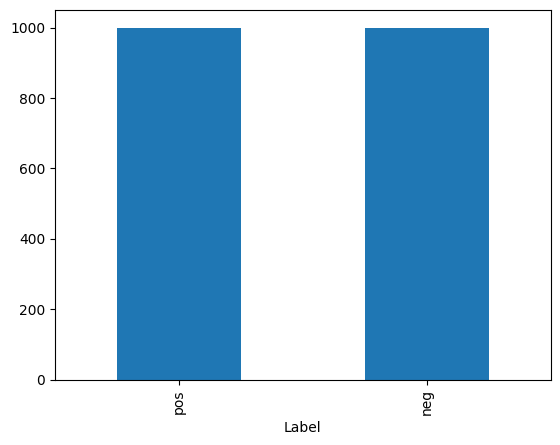

In [16]:
df['Label'].value_counts().plot(kind='bar')

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Review'])
y = df['Label']

In [18]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 6843)	1
  (0, 24150)	2
  (0, 21399)	1
  (0, 11066)	1
  (0, 10166)	1
  (0, 18005)	2
  (0, 14752)	2
  (0, 12691)	3
  (0, 11410)	8
  (0, 902)	2
  (0, 10086)	2
  (0, 12985)	3
  (0, 15428)	1
  (0, 4464)	1
  (0, 4742)	2
  (0, 16381)	1
  (0, 12402)	1
  (0, 15946)	1
  (0, 21903)	1
  (0, 4744)	1
  (0, 5751)	2
  (0, 1601)	1
  (0, 523)	1
  (0, 21251)	2
  (0, 24771)	1
  :	:
  (1999, 6976)	1
  (1999, 7581)	1
  (1999, 21040)	1
  (1999, 24914)	1
  (1999, 20272)	1
  (1999, 25134)	1
  (1999, 21499)	1
  (1999, 2351)	1
  (1999, 5566)	1
  (1999, 11632)	1
  (1999, 3384)	1
  (1999, 9819)	1
  (1999, 2088)	1
  (1999, 17113)	1
  (1999, 11443)	1
  (1999, 4862)	1
  (1999, 759)	1
  (1999, 25153)	1
  (1999, 24964)	1
  (1999, 15927)	1
  (1999, 15684)	1
  (1999, 16642)	1
  (1999, 6020)	1
  (1999, 4911)	1
  (1999, 8781)	1
0       pos
1       pos
2       pos
3       neg
4       neg
       .

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix

print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.8275


Text(0.5, 1.0, 'Confusion Matrix')

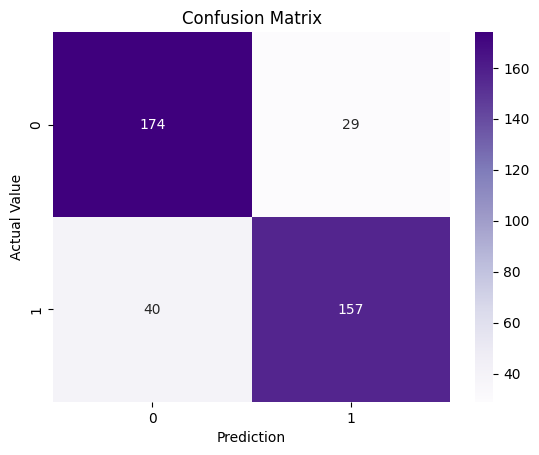

In [31]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.xlabel('Prediction')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix')